<a href="https://colab.research.google.com/github/Aditipetkar/Aditi/blob/main/fraud_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

In [19]:
df = pd.read_csv("/content/sample_data/Fraud.csv")
print("Shape of the dataset:", df.shape)
df.head()

Shape of the dataset: (4518853, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0


In [20]:
#Check Missing Values
print("Missing values per column:\n", df.isnull().sum())

Missing values per column:
 step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    1
isFraud           1
isFlaggedFraud    1
dtype: int64


In [22]:
## Drop rows with missing target values
df = df[df['isFraud'].notnull()]


In [23]:
## Drop rows with any remaining NaNs in predictors
df = df.dropna()

In [24]:
 #Detect Outliers (using IQR)
numeric_cols = df.select_dtypes(include=np.number).columns
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
    print(f"Outliers in {col}: {len(outliers)}")

Outliers in step: 0
Outliers in amount: 234091
Outliers in oldbalanceOrg: 792681
Outliers in newbalanceOrig: 745891
Outliers in oldbalanceDest: 548145
Outliers in newbalanceDest: 511425
Outliers in isFraud: 3663
Outliers in isFlaggedFraud: 3


In [25]:
#Check Multicollinearity
X_temp = df[numeric_cols].dropna()
vif_data = pd.DataFrame()
vif_data["Feature"] = X_temp.columns
vif_data["VIF"] = [variance_inflation_factor(X_temp.values, i) for i in range(X_temp.shape[1])]
print(vif_data)

          Feature         VIF
0            step    1.194554
1          amount    3.925547
2   oldbalanceOrg  694.513834
3  newbalanceOrig  697.485226
4  oldbalanceDest   43.744418
5  newbalanceDest   54.367118
6         isFraud    1.127158
7  isFlaggedFraud    1.000910


In [26]:
#Preprocessing & Train-Test Split
## Assume 'isFraud' is the target column
y = df['isFraud']
X = df.drop('isFraud', axis=1)

In [27]:
# Drop columns with high cardinality or IDs
X = X.drop(['userId', 'sessionId'], axis=1, errors='ignore')

In [28]:
# Label Encoding for medium to high-cardinality features
label_enc = LabelEncoder()
if 'locationId' in X.columns:
    X['locationId'] = label_enc.fit_transform(X['locationId'])

In [29]:
# One-hot encode only low-cardinality categorical features
low_card_cols = [col for col in X.select_dtypes(include='object').columns if X[col].nunique() < 50]
X = pd.get_dummies(X, columns=low_card_cols, drop_first=True)

In [30]:
# Feature Scaling
scaler = StandardScaler()
X_numeric = X.select_dtypes(include=[np.number])  # Avoid objects
X_scaled = scaler.fit_transform(X_numeric)

In [31]:
# Handle Imbalance with SMOTE
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_scaled, y)


In [32]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.3, random_state=42)


In [34]:
from sklearn.ensemble import RandomForestClassifier

# Original model (potentially slow)
# model = RandomForestClassifier(n_estimators=1000, max_depth=None, n_jobs=-1)

# Optimized model for faster training
model = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=5, n_jobs=-1)

# Fit the model
# model.fit(X_train, y_train)

In [35]:
#Model Building
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [36]:
 #Evaluation
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_pred))


[[1354249    1349]
 [     46 1353470]]
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00   1355598
         1.0       1.00      1.00      1.00   1353516

    accuracy                           1.00   2709114
   macro avg       1.00      1.00      1.00   2709114
weighted avg       1.00      1.00      1.00   2709114

ROC AUC Score: 0.9994854408320397


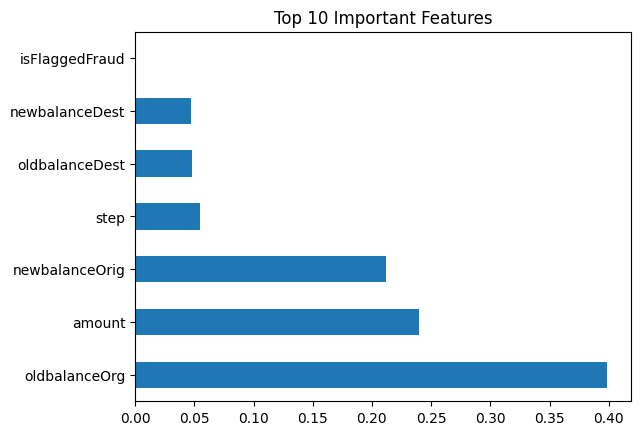

In [37]:
 #Feature Importance
importances = model.feature_importances_
feat_names = X_numeric.columns
feat_importance = pd.Series(importances, index=feat_names)
feat_importance.nlargest(10).plot(kind='barh')
plt.title("Top 10 Important Features")
plt.show()
